In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import uniform, seed
seed(12345)

## MC integration

Calculate the integral $\int_0^1 x^n \sin(\alpha\pi x){\rm d}x$ for $n=20$, $\alpha=20.5$ using the Monte Carlo method with 1000 uniformly distributed samples.


In [2]:
def f(x, n=20, alpha=20.5): return x**n*np.sin(np.pi*alpha*x)

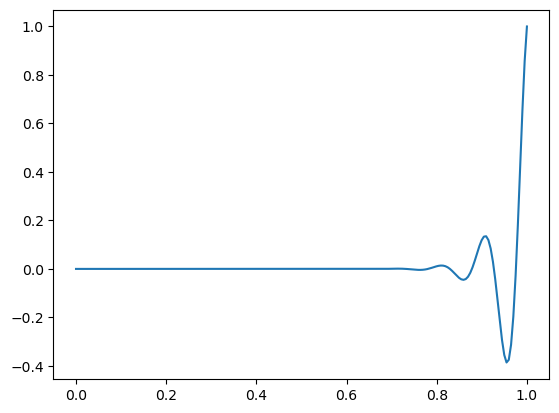

In [3]:
x = np.linspace(0, 1, 200)
plt.plot(x, f(x))

In [4]:
def integrate_MC(f, a, b, nsampl):
    xsamples = uniform(a, b, nsampl)
    fsamples = f(xsamples)
    integral = np.mean(fsamples)*(b-a)
    return integral

In [5]:
integrate_MC(f, 0, 1, 1000)

0.0020830159520968134

Estimate the error of the calculation. Repeat for 1, 10, 100,.... 100000 samples

In [6]:
def test_integrate_MC(f, a, b, nsampl, ntest, integrator=integrate_MC):
    integrals = [integrator(f, a, b, nsampl) for _ in range(ntest)]
    return np.mean(integrals), np.std(integrals)

In [7]:
nsampls = 10**np.arange(6)
ntest = 20

In [8]:
integrals = np.array([test_integrate_MC(f, 0, 1, nsampl, ntest) for nsampl in nsampls])

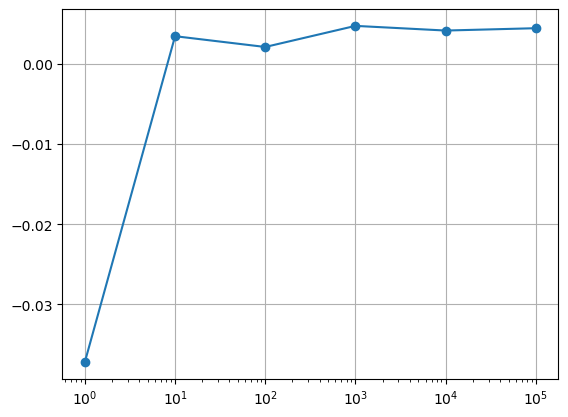

In [9]:
plt.plot(nsampls, integrals[:,0], "-o")
plt.gca().set_xscale("log")
plt.grid()

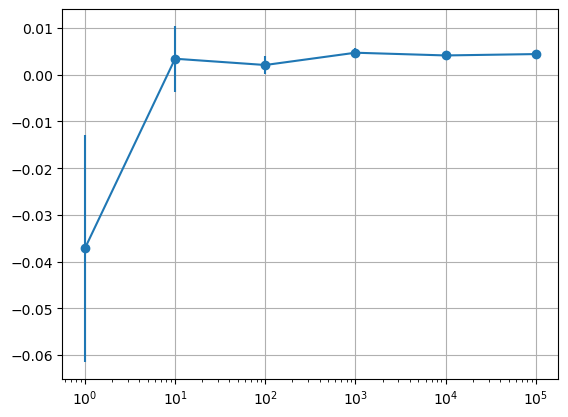

In [10]:
plt.errorbar(nsampls, integrals[:,0], fmt="-o", yerr=integrals[:,1]/np.sqrt(ntest))
plt.gca().set_xscale("log")
plt.grid()

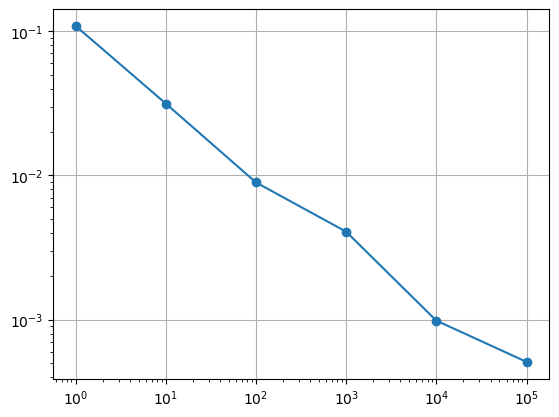

In [12]:
plt.loglog(nsampls, integrals[:,1], "-o")
plt.gca().set_xscale("log")
plt.grid()